# Lab 1: Models, pictures and reflection
**Python supplement · Worked solutions · English**

Use arrays to represent shapes; compare a finite family of competitors; distinguish a sampled minimum from an exact geometric answer.

These two exercises supplement the mathematical lab; they are not
additional required work inside its original 90-minute schedule.
Allow roughly 60–90 minutes, depending on Python experience.

Run the setup cell first, then work from top to bottom. The task functions
are completed in this version. The demonstration cells generate the figures
and run mathematical checks; discussion guidance follows each exercise.

A plot, finite search or successful iteration supplies numerical
evidence. State separately any theorem used to establish existence,
global optimality or an equality case.


This version contains completed code and discussion guidance. All plots and checks can be reproduced with **Restart Kernel and Run All**.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.figsize': (9, 4), 'font.size': 11,
                     'axes.grid': True, 'grid.alpha': 0.25,
                     'figure.constrained_layout.use': True})

def closed(v):
    """Repeat the first vertex only for plotting."""
    return np.vstack([v, v[0]])

def area(v):
    """Unsigned shoelace area of an ordered simple polygon."""
    return abs(np.sum(v[:, 0]*np.roll(v[:, 1], -1)
                      - v[:, 1]*np.roll(v[:, 0], -1)))/2

def perimeter(v):
    return np.linalg.norm(np.roll(v, -1, axis=0)-v, axis=1).sum()

def outline(ax, v, **kwargs):
    p = closed(v)
    ax.plot(p[:, 0], p[:, 1], **kwargs)
    ax.set_aspect('equal', adjustable='box')




## Exercise 1.1: Equal perimeter, different areas

**Mathematics.** A string of length $L=12$ bounds an equilateral triangle,
a square or a circle. For a regular $n$-gon, the circumradius is
$R=L/(2n\sin(\pi/n))$ and its vertices are
$R(\cos(2k\pi/n),\sin(2k\pi/n))$.

**Code tasks (25–35 minutes).**
1. Complete `compare_shapes(L)` to return triangle vertices, square vertices
   and the three areas, in that order. Use the supplied shoelace `area`.
2. Draw the three competitors on the same scale and make an area bar chart.
3. Change $L$ to $6$ and $24$. Check that lengths scale by $L$ and areas by $L^2$.

**Return contract:** `(triangle, square, areas)`, with vertex arrays of shapes
`(3, 2)` and `(4, 2)`, and a length-three area array. Do not repeat the first
vertex in the arrays used for computation. The circle area is analytic;
the points used to draw it are only a rendering approximation.


In [2]:
def compare_shapes(L):
    polygons = []
    for n in (3, 4):
        theta = 2*np.pi*np.arange(n)/n
        radius = L/(2*n*np.sin(np.pi/n))
        polygons.append(radius*np.column_stack([np.cos(theta), np.sin(theta)]))
    tri, square = polygons
    return tri, square, np.array([area(tri), area(square), L**2/(4*np.pi)])


**Run, visualize and check.** Adapt these plots as requested, and report what changes when you refine the discretization or vary parameters.

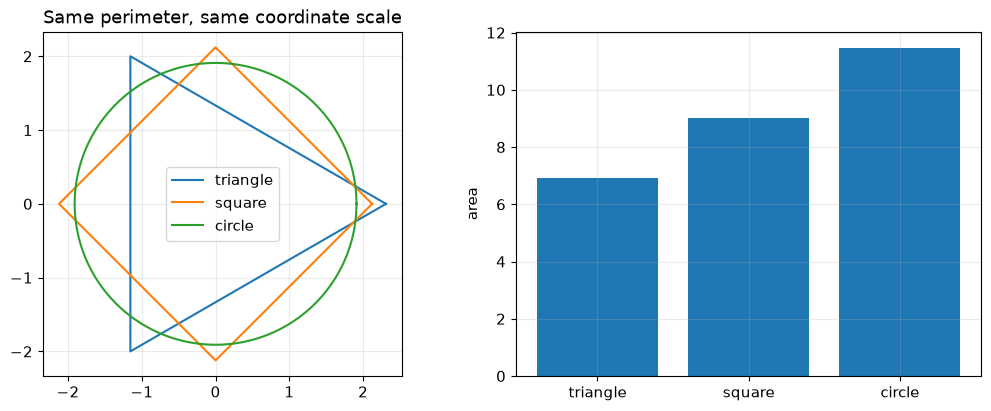

Area and scaling checks passed: [ 6.92820323  9.         11.4591559 ]


In [3]:
L = 12.0
result = compare_shapes(L)
if result is None:
    print('Complete compare_shapes, then rerun this cell.')
else:
    tri, square, values = result
    np.testing.assert_allclose([perimeter(tri), perimeter(square)], L)
    np.testing.assert_allclose(values, [L**2/(12*np.sqrt(3)), L**2/16, L**2/(4*np.pi)])
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    outline(ax[0], tri, label='triangle')
    outline(ax[0], square, label='square')
    t = np.linspace(0, 2*np.pi, 361)
    ax[0].plot(L/(2*np.pi)*np.cos(t), L/(2*np.pi)*np.sin(t), label='circle')
    ax[0].legend(); ax[0].set_title('Same perimeter, same coordinate scale')
    ax[1].bar(['triangle', 'square', 'circle'], values)
    ax[1].set_ylabel('area'); plt.show()
    for length in (6.0, 24.0):
        np.testing.assert_allclose(compare_shapes(length)[2]/values, (length/L)**2)
    print('Area and scaling checks passed:', values)


**Explain your observations.** Which candidate wins this comparison? Why does comparing three shapes not prove the isoperimetric inequality?

**Solution guidance:** The circle wins this three-shape comparison. Scaling all lengths by a factor c multiplies areas by c². The global isoperimetric theorem requires a bound over the entire admissible class, not just these three examples.

## Exercise 1.2: Heron's problem: a grid search meets a reflection

**Mathematics.** Let $A=(0,2)$, $B=(6,4)$ and $X=(t,0)$.
Minimize $f(t)=|A-X|+|X-B|$. Reflect $B$ in the horizontal axis and
intersect $AB'$ with that axis to find the exact contact point.

**Code tasks (30–40 minutes).**
1. Complete `reflected_search(A, B, samples)`. Evaluate the distance sum
   at all supplied `samples`, locate its smallest value, and compute the
   exact reflected-line intersection without differentiating.
2. Plot the distance curve and the two broken paths. Repeat with 21, 81
   and 321 equally spaced sample points on $[-1,7]$.
3. Record contact-point error and objective error. A grid that happens
   to contain the exact answer can have zero error even when coarse.

**Return contract:** `(values, t_grid, t_exact)`. Assume both endpoint
heights are strictly positive. Test another pair of endpoints afterwards.


In [4]:
def reflected_search(A, B, samples):
    points = np.column_stack([samples, np.zeros_like(samples)])
    values = np.linalg.norm(points-A, axis=1) + np.linalg.norm(points-B, axis=1)
    reflected = B*np.array([1., -1.])
    fraction = A[1]/(A[1]-reflected[1])
    t_exact = (A + fraction*(reflected-A))[0]
    return values, samples[np.argmin(values)], t_exact


**Run, visualize and check.** Adapt these plots as requested, and report what changes when you refine the discretization or vary parameters.

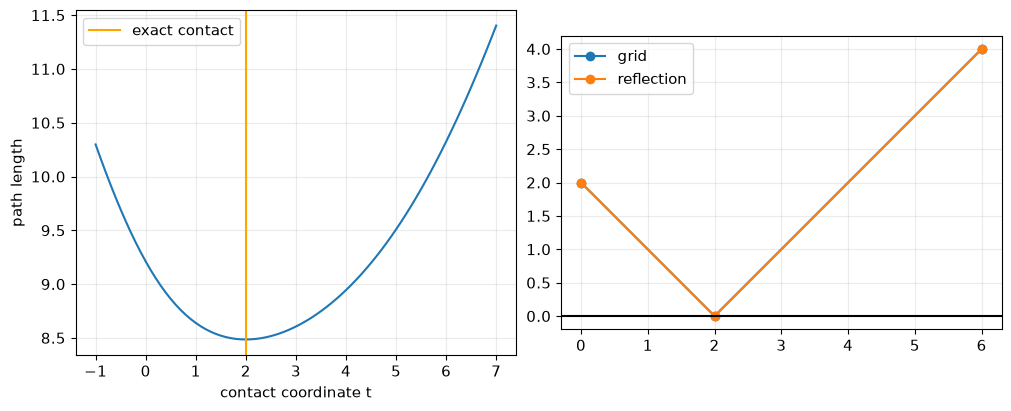

 21 points: contact error=0.2, length error=0.00517806
 81 points: contact error=0, length error=1.77636e-15
321 points: contact error=0, length error=1.77636e-15


In [5]:
A, B = np.array([0., 2.]), np.array([6., 4.])
samples = np.linspace(-1, 7, 81)
result = reflected_search(A, B, samples)
if result is None:
    print('Complete reflected_search, then rerun this cell.')
else:
    values, tg, te = result
    np.testing.assert_allclose(te, 2.)
    exact_value = np.linalg.norm(A-np.array([B[0], -B[1]]))
    assert values.min() >= exact_value-1e-12
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    ax[0].plot(samples, values); ax[0].axvline(te, color='orange', label='exact contact')
    ax[0].set(xlabel='contact coordinate t', ylabel='path length'); ax[0].legend()
    for t, label in [(tg, 'grid'), (te, 'reflection')]:
        path = np.vstack([A, [t, 0.], B])
        ax[1].plot(path[:, 0], path[:, 1], 'o-', label=label)
    ax[1].axhline(0, color='black'); ax[1].set_aspect('equal'); ax[1].legend()
    plt.show()
    for count in (21, 81, 321):
        vals, grid_t, exact_t = reflected_search(A, B, np.linspace(-1, 7, count))
        print(f'{count:3d} points: contact error={abs(grid_t-exact_t):.6g}, '
              f'length error={vals.min()-exact_value:.6g}')


**Explain your observations.** Explain the global geometric lower bound. Which part of the computation is a discretization, and which part uses an exact formula?

**Solution guidance:** Reflection gives the lower bound |A−B′| for every contact point. Its attaining point has t=2 and length √72. A sampled minimum is an upper bound on the true minimum; endpoint and objective errors depend on whether the grid contains t=2.

**Before submitting:** restart the kernel, run all cells in order, check axis labels and units, and explain any discrepancy between numerical and exact quantities.